Unemployment Analysis with Python
Oasis Infobyte Data Science Internship - Task 2
Name: Prateek Negi

Objective: The objective of this project is to perform Exploratory Data Analysis (EDA) on India's unemployment dataset to identify regional and temporal trends, analyze the impact of the COVID-19 pandemic on unemployment rates, and visualize important insights using Python.

Import Required Libraries
In this step, we import all the libraries required for data manipulation, visualization, and analysis throughout the project.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [ ]:
df = pd.read_csv('/content/Unemployment in India.csv')
display(df.head())

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [ ]:
df.columns = df.columns.str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
 7   Month                                    740 non-null    int32         
 8   Year                                     740 non-null    int32         
 9   Month_name                               740 non

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
 7   Month                                    740 non-null    int32         
 8   Year                                     740 non-null    int32         
 9   Month_name                               740 non

In [ ]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0
Month,0
Year,0


In [ ]:
df.dropna(inplace=True)
df.shape

(740, 10)

In [ ]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year,Month_name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5,2019,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6,2019,Jun
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7,2019,Jul
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8,2019,Aug
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9,2019,Sep


In [ ]:
df['Month_name'] = df['Month'].apply(lambda x: calendar.month_abbr[x])
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year,Month_name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5,2019,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6,2019,Jun
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7,2019,Jul
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8,2019,Aug
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9,2019,Sep


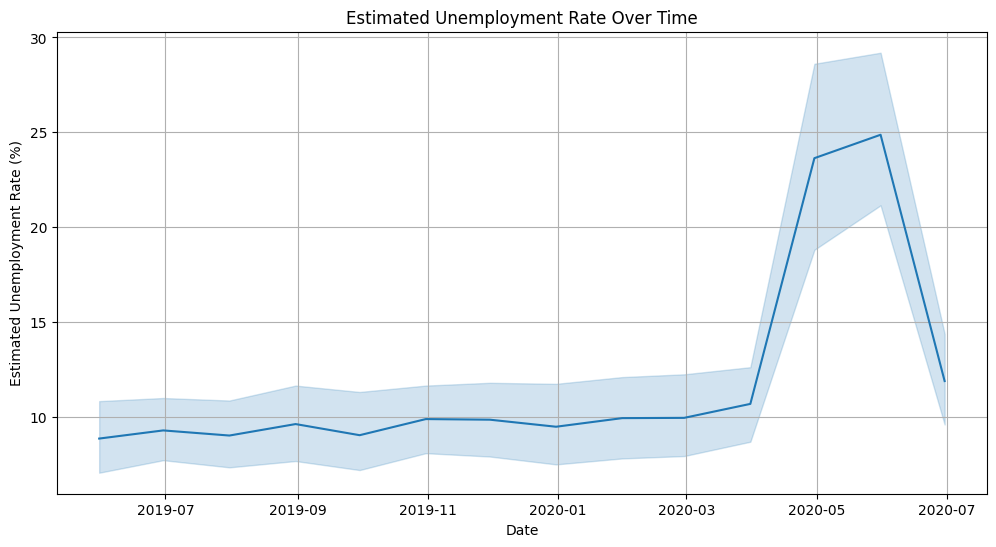

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)')
plt.title('Estimated Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True)
plt.show()

In [ ]:
region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
print(region_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


/tmp/ipykernel_1351/3994896431.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_unemployment.index, y=region_unemployment.values, palette='viridis')


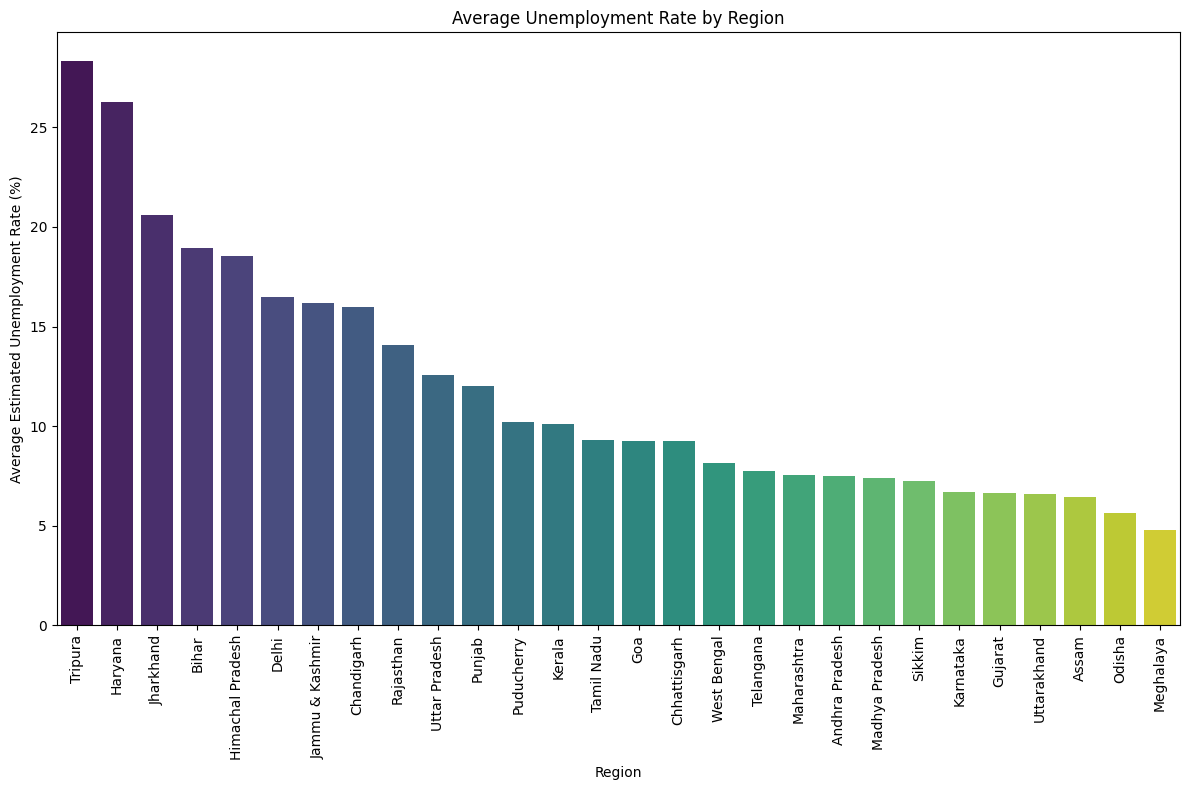

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x=region_unemployment.index, y=region_unemployment.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.tight_layout()
plt.show()

In [ ]:
area_unemployment = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
print(area_unemployment)

Area
Urban    13.166614
Rural    10.324791
Name: Estimated Unemployment Rate (%), dtype: float64


/tmp/ipykernel_1351/859657931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_unemployment.index, y=area_unemployment.values, palette='coolwarm')


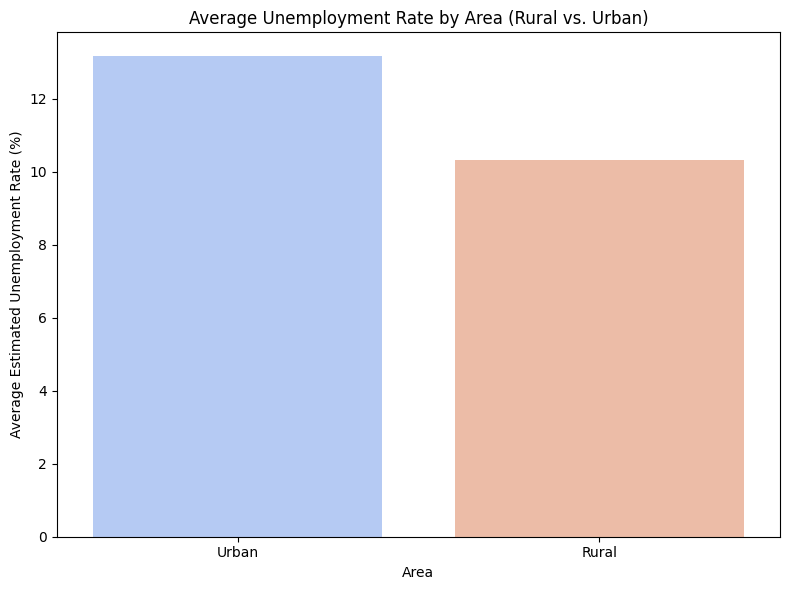

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=area_unemployment.index, y=area_unemployment.values, palette='coolwarm')
plt.title('Average Unemployment Rate by Area (Rural vs. Urban)')
plt.xlabel('Area')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.tight_layout()
plt.show()

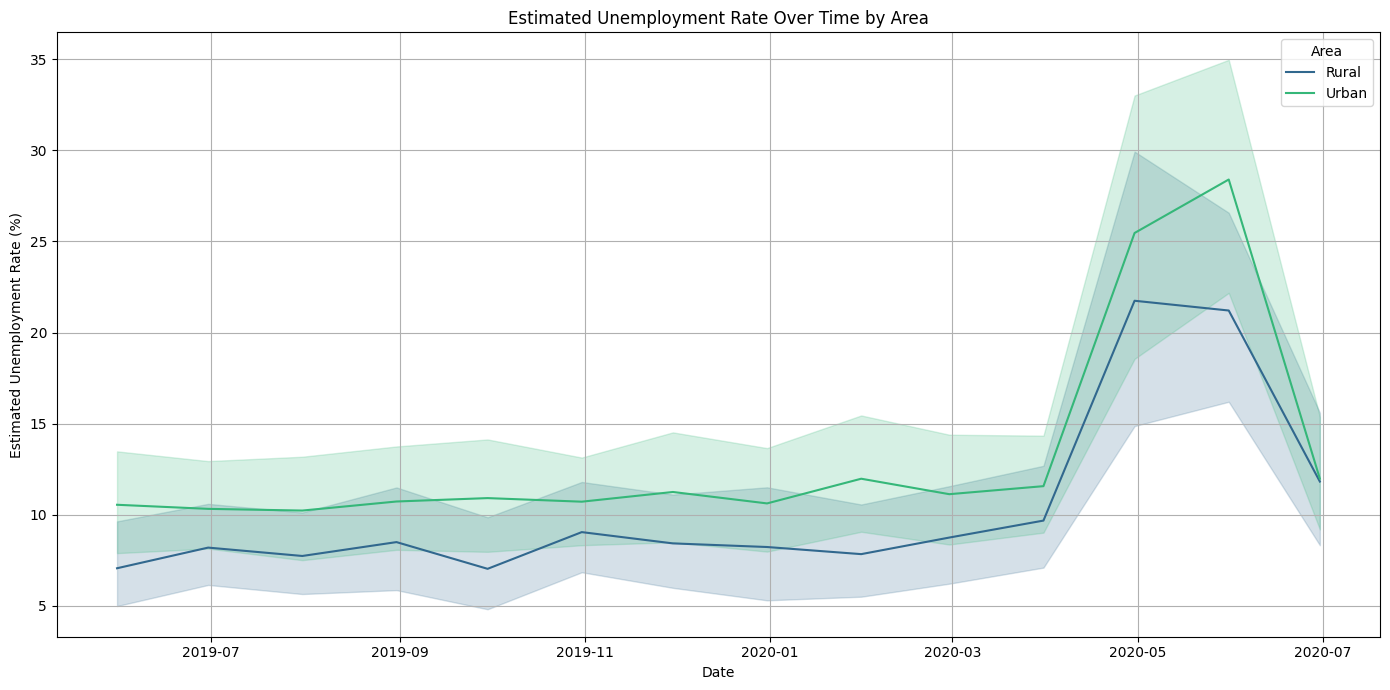

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', palette='viridis')
plt.title('Estimated Unemployment Rate Over Time by Area')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True)
plt.legend(title='Area')
plt.tight_layout()
plt.show()

In [ ]:
df_unemployment_covid = df[(df['Month_name'] == 'Apr') | (df['Month_name'] == 'May') | (df['Month_name'] == 'Jun')]
lockdown_unemployment = df_unemployment_covid.groupby('Area')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
print(lockdown_unemployment)

Area
Urban    17.177293
Rural    13.909843
Name: Estimated Unemployment Rate (%), dtype: float64


/tmp/ipykernel_1351/919526010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lockdown_unemployment.index, y=lockdown_unemployment.values, palette='plasma')


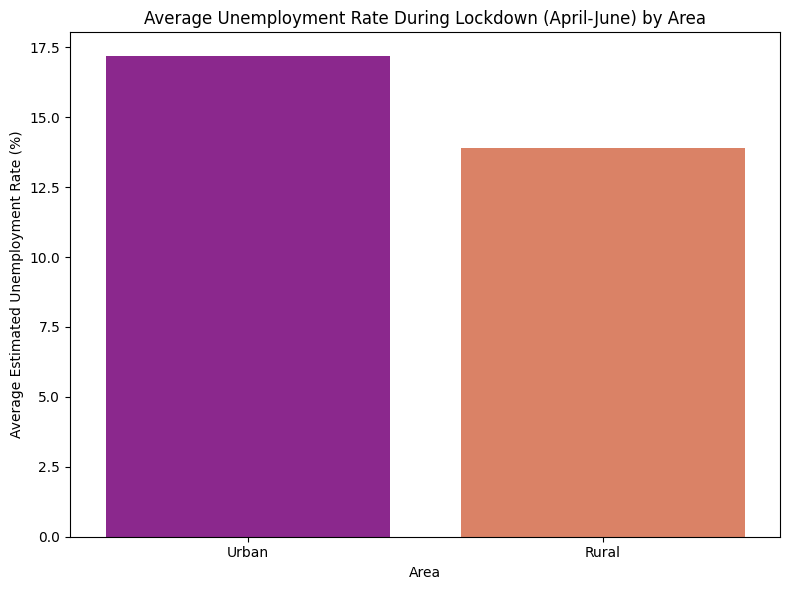

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=lockdown_unemployment.index, y=lockdown_unemployment.values, palette='plasma')
plt.title('Average Unemployment Rate During Lockdown (April-June) by Area')
plt.xlabel('Area')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.tight_layout()
plt.show()